## 0: Autosave and Imports

In [1]:
%autosave 60
%pip install --quiet -r requirements.txt

Autosaving every 60 seconds
Note: you may need to restart the kernel to use updated packages.


In [2]:
import yaml
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from utils.mri.data_loader import DataLoader
from utils.mri.data_converter import DataConverter
from utils.model_utils.grid_search import create_hyperparameter_grid, run_pipeline, select_champions
from utils.model_utils.bayes_search import init_yaml, run_bayes, select_bayes_champions
from utils.model_utils.train_eval import get_middle_slice_3D
from utils.model_utils.loss_functions import ssim_loss, l1_loss
from utils.analysis.data_analyser import DataAnalyser
from utils.metadata.health_data_utils import HealthDataLoader
from utils.metadata.fastsurfer_utils import FastSurferLoader, generate_all_csvs
from utils.metadata.combined_metadata_utils import CombinedMetadataUtils
from utils.metadata.stratified_splitter import StratifiedSplitter

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

/home/conda/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda:0


## 1. Data Setup
First prepare all the data used for training. All funcitons are safe to run multiple times, and will just skip preprocessing if it's aleady done :)

In [ ]:
root_path       = 'data/'
metadata_root   = 'data/metadata'
healthdata_root = 'data/metadata/health_data'
processed_dir   = 'data/metadata/processed'
fastsurfer_root = 'data/metadata/hdd/sMRI_generated'
final_data_path = 'data/metadata/combined_metadata.csv'
overwrite_data  = True
random_seed     = 69

grid_path       = 'out/grid_search/grid_search.yaml'
bayes_path      = 'out/bayes_search/bayes_search.yaml'

data_loader     = DataLoader(root_path=root_path)
health_loader   = HealthDataLoader(root=metadata_root)
fs_loader       = FastSurferLoader(root=fastsurfer_root)
comb_loader     = CombinedMetadataUtils()

data_splitter   = StratifiedSplitter()

data_converter = DataConverter()
data_analyser  = DataAnalyser(root_path=root_path)

Convert data from SAV to CSV

In [4]:
mapping_path = health_loader.sav_to_csv(overwrite=overwrite_data)

[sav_to_csv] Saved 772 rows → data/metadata/processed/id_mapping.csv


Load Health data, generating a normalized_health_data.csv

In [9]:
health_data_path = health_loader.generate_normalized(overwrite=overwrite_data,health_features_path=metadata_root, out_dir=processed_dir)

FileNotFoundError: [Errno 2] No such file or directory: 'data/metadata/health_data/HUNT3.csv'

Generate CSV files containing all the stats from FreeSurfer

In [ ]:
generate_all_csvs(overwrite=overwrite_data, subjects_dir="data/metadata/hdd/full", output_dir=fastsurfer_root)

Processing subjects: 100%|██████████| 993/993 [00:00<00:00, 74762.50it/s]

generate_all_csvs: 0 written, 993 skipped, 0 failed (993 subjects in 'data/metadata/hdd/full')


['/home/ubuntu/NTNU-Master-project/data/metadata/hdd/sMRI_generated/MRI_9410000000039_all.csv',
 '/home/ubuntu/NTNU-Master-project/data/metadata/hdd/sMRI_generated/MRI_9410000000046_all.csv',
 '/home/ubuntu/NTNU-Master-project/data/metadata/hdd/sMRI_generated/MRI_9410000000053_all.csv',
 '/home/ubuntu/NTNU-Master-project/data/metadata/hdd/sMRI_generated/MRI_9410000000077_all.csv',
 '/home/ubuntu/NTNU-Master-project/data/metadata/hdd/sMRI_generated/MRI_9410000000091_all.csv',
 '/home/ubuntu/NTNU-Master-project/data/metadata/hdd/sMRI_generated/MRI_9410000000107_all.csv',
 '/home/ubuntu/NTNU-Master-project/data/metadata/hdd/sMRI_generated/MRI_9410000000114_all.csv',
 '/home/ubuntu/NTNU-Master-project/data/metadata/hdd/sMRI_generated/MRI_9410000000121_all.csv',
 '/home/ubuntu/NTNU-Master-project/data/metadata/hdd/sMRI_generated/MRI_9410000000138_all.csv',
 '/home/ubuntu/NTNU-Master-project/data/metadata/hdd/sMRI_generated/MRI_9410000000145_all.csv',
 '/home/ubuntu/NTNU-Master-project/data/

Load Fastsurfer data, generating a normalized_fastsurfer_data.csv

In [ ]:
fs_data_path = fs_loader.load_and_normalize(overwrite=overwrite_data, in_dir=fastsurfer_root, out_dir=processed_dir)

[load] data/metadata/processed/fastsurfer_data.csv exists — skipping (pass overwrite=True to reprocess)
[normalize] data/metadata/processed/fastsurfer_data_normalized.csv exists — skipping (pass overwrite=True to renormalize)


Combine data into a single csv table, which we can use going forward

In [ ]:
comb_loader.get_overlap(health_data_path=health_data_path, fastsurfer_data_path=fs_data_path);

Health data:      703 subjects
FastSurfer data:  731 subjects
Overlap:          703 subjects
Health only:      0 subjects
FastSurfer only:  28 subjects


In [ ]:
metadata_path = comb_loader.combine(overwrite=overwrite_data, health_data_path=health_data_path, fastsurfer_data_path=fs_data_path, output_path=metadata_root)
metadata_df = pd.read_csv(metadata_path)
metadata_df.head()

[combine] data/metadata/metadata_combined.csv exists — skipping (pass overwrite=True to regenerate)


,hunt_id,age,employment_status,waist_circumference_cm,hip_circumference_cm,diastolic_bp_mmhg,systolic_bp_mmhg,blood_glucose_mmol_l,bmi_kg_m2,pack_years,...,frontal_thickness_mean,frontal_volume_total,parietal_thickness_mean,parietal_volume_total,temporal_thickness_mean,temporal_volume_total,occipital_thickness_mean,occipital_volume_total,insula_thickness_mean,insula_volume_total
0,22866,0.082061,0.0,0.566754,0.352740,0.666118,0.584416,0.194767,0.342857,0.221757,...,0.637206,0.473164,0.727898,0.546183,0.682324,0.524126,0.542459,0.383355,0.510161,0.483112
1,10357,0.811256,1.0,0.585079,0.159247,0.587171,0.501299,0.273256,0.278571,0.000000,...,0.598608,0.720253,0.688969,0.763546,0.597384,0.563911,0.533725,0.634453,0.604499,0.737017
2,12126,0.626695,0.0,0.468586,0.770548,0.177632,0.374026,0.491279,0.610714,0.357741,...,0.674263,0.765947,0.710331,0.610791,0.657201,0.683547,0.425980,0.445698,0.664529,0.826045
3,22223,0.255568,0.0,0.492147,0.613014,0.383224,0.322944,0.430233,0.496429,0.080544,...,0.648222,0.520588,0.706014,0.568059,0.722516,0.531147,0.580186,0.586900,0.384561,0.409118
4,17400,0.371794,0.0,0.684555,0.602740,0.613487,0.410390,0.420058,0.517857,0.000000,...,0.609523,0.560886,0.615017,0.490775,0.652423,0.535264,0.463316,0.355230,0.678619,0.512300


### Split dataset based on features

In [ ]:
train, val, test = data_splitter.split(metadata_df, id_col="hunt_id", save_path="data/metadata/splits.json", train_split=0.7, val_split=0.15, seed=random_seed)

# Print the number of samples in each split
print(f"Train samples: {len(train)}")
print(f"Validation samples: {len(val)}")
print(f"Test samples: {len(test)}")

[StratifiedSplitter] Split saved → data/metadata/splits.json
Train samples: 482
Validation samples: 106
Test samples: 115


## 2. Run Models

In [ ]:
init_yaml(yaml_file=bayes_path, epochs=4000, base_channels=16, restart_threshold=0.2, restart_check_epoch=500, max_total_runs=3)

In [ ]:
print(f"Train pairs: {len(train)}  Val pairs: {len(val)}")
train_pairs = [data_loader.get_pair_path_from_id(hunt_id) for hunt_id in train]
val_pairs   = [data_loader.get_pair_path_from_id(hunt_id) for hunt_id in val]

run_bayes(
    yaml_file=bayes_path,
    db_path='data/bayes_search.db',
    train_pairs=train_pairs,
    val_pairs=val_pairs,
    n_trials=10,
    metadata_root=metadata_root,
    out_dir='out/bayes_search',
    device=device,
)

Train pairs: 482  Val pairs: 106
[bayes_search] epochs=4000  base_channels=16  restart_threshold=0.2  restart_check_epoch=500  max_total_runs=3
[bayes_search] Marked interrupted trial 5 in bayes_std as FAIL
[bayes_search] Cleanup done — 1 Optuna trial(s) failed, 0 YAML entry(s) dropped

[bayes_search] Starting film_simple_trial_010
  lr=5.61e-05  wd=7.11e-04  beta1=0.909  beta2=0.979  sched=cosine  film_type=simple  mlp_hidden=36


Training 3D U-Net with Features [run 1/3]:   0%|          | 0/4000 [00:00<?, ?it/s]/home/ubuntu/NTNU-Master-project/utils/model_utils/train_eval.py:335: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1772176447874/work/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  if i % checkpoint_every == 0 and float(y_hat.abs().mean()) < 1e-4:
Training 3D U-Net with Features [run 1/3]:   0%|          | 0/4000 [02:08<?, ?it/s]


KeyboardInterrupt: 

## 3. Fetch the Champions

Run these cells after all three models are trained (or loaded from disk).

In [ ]:
with open(grid_path) as f:
    grid_doc = yaml.safe_load(f)


completed = [e for e in grid_doc['grid'] if e.get('results', {}).get('completed')]
print(f"Completed: {len(completed)} / {len(grid_doc['grid'])} entries\n")

rows = []
for e in completed:
    r = e['results']
    rows.append({
        'id':            e['id'],
        'model_type':    e['model_type'],
        'film_type':     e.get('film_generator_type', '—'),
        'lr':            e['learning_rate'],
        'weight_decay':  e['weight_decay'],
        'scheduler':     e['lr_scheduler'],
        'mlp_hidden':    e.get('mlp_hidden', '—'),
        'best_val_loss': r['best_val_loss'],
        'trained_at':    r.get('trained_at', ''),
    })

df = pd.DataFrame(rows).sort_values('best_val_loss').reset_index(drop=True)
display(df)

Completed: 0 / 80 entries



KeyError: 'best_val_loss'

In [ ]:
champions = select_champions(grid_file=grid_path, device=device, metadata_root=metadata_root)
print(champions)

[select_champions] std: std_003  val_loss=0.784144  ← out/grid_search/std_003_best.pth
[select_champions] film_simple: film_simple_032  val_loss=0.700691  ← out/grid_search/film_simple_032_best.pth
[select_champions] film_complex: film_complex_032  val_loss=0.836862  ← out/grid_search/film_complex_032_best.pth
{'std': UNet3D(
  (e1): ConvBlock(
    (block): Sequential(
      (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (1): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.1, inplace=True)
      (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (4): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (5): LeakyReLU(negative_slope=0.1, inplace=True)
    )
  )
  (e2): Down(
    (conv): ConvBlock(
      (block): Sequential(
        (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride

## 5. Evaluate The Champions performance

In [ ]:
from utils.train_eval import get_metadata_features

def evaluate_model(model, pairs, conditional=False):
    model.eval()
    data_device = next(model.parameters()).device
    ssim_vals, l1_vals = [], []

    with torch.no_grad():
        for x_path, y_path in tqdm(pairs, desc='Evaluating'):
            x_full = data_converter.load_path_as_tensor(x_path, data_device)
            y_full = data_converter.load_path_as_tensor(y_path, data_device)
            x = data_converter.get_volume_with_3d_change(x_full, ((16, 10, 0), (17, 11, 17)), remove_mode=True).to(data_device)
            y = data_converter.get_volume_with_3d_change(y_full, ((16, 10, 0), (17, 11, 17)), remove_mode=True).to(data_device)

            if conditional:
                cond = get_metadata_features(cond_loader, x_path).unsqueeze(0).to(data_device)
                out  = model(x, cond)
            else:
                out = model(x)

            y_hat = out[0] if isinstance(out, (tuple, list)) else out
            ssim_vals.append(ssim_loss(y_hat, y).item())
            l1_vals.append(l1_loss(y_hat, y).item())
            del x_full, y_full, x, y, out, y_hat

    return dict(
        ssim_mean=float(np.mean(ssim_vals)),
        ssim_std=float(np.std(ssim_vals)),
        l1_mean=float(np.mean(l1_vals)),
        l1_std=float(np.std(l1_vals)),
    )

test_results = {}
for key, model in champions.items():
    print(f'Evaluating {key}...')
    test_results[key] = evaluate_model(model, test_pairs, conditional=key.startswith('film'))


Evaluating std...


Evaluating:   2%|▏         | 2/113 [00:03<03:10,  1.71s/it]


KeyboardInterrupt: 

### Estimate DICE

In [ ]:
import os, sys, subprocess
import nibabel as nib

FASTSURFER_DIR = os.path.join(os.path.expanduser("~"), "FastSurfer")
GT_SEG_DIR     = "out/hunt4_gt/segmentations"
THRESHOLD      = 1e-3

os.makedirs(GT_SEG_DIR, exist_ok=True)

GM_LABELS = set([
    *range(1000, 1036), *range(2000, 2036),
    10, 11, 12, 13, 17, 18, 26, 28,
    49, 50, 51, 52, 53, 54, 58, 60,
])
WM_LABELS  = set([2, 41, 7, 46, 77, 85, 251, 252, 253, 254, 255])
CSF_LABELS = set([4, 5, 14, 15, 24, 31, 43, 44, 63, 72])

def to_binary_mask(seg_vol, label_set):
    mask = np.zeros(seg_vol.shape, dtype=bool)
    for label in label_set:
        mask |= (seg_vol == label)
    return mask

def dice_coefficient(mask_pred, mask_gt):
    intersection = np.logical_and(mask_pred, mask_gt).sum()
    total = mask_pred.sum() + mask_gt.sum()
    return float('nan') if total == 0 else 2.0 * float(intersection) / float(total)

def volumetric_similarity(mask_pred, mask_gt):
    v_pred = float(mask_pred.sum())
    v_gt   = float(mask_gt.sum())
    denom  = v_pred + v_gt
    return float('nan') if denom == 0 else 1.0 - abs(v_pred - v_gt) / denom

def run_fastsurfer_seg(input_path, output_path):
    abs_out = os.path.abspath(output_path)
    sid     = os.path.basename(os.path.dirname(abs_out))
    sd      = os.path.dirname(os.path.dirname(abs_out))
    os.makedirs(os.path.dirname(abs_out), exist_ok=True)
    cmd = [
        sys.executable,
        os.path.join(FASTSURFER_DIR, "FastSurferCNN", "run_prediction.py"),
        "--t1",              os.path.abspath(input_path),
        "--asegdkt_segfile", abs_out,
        "--sd",              sd, "--sid", sid,
        "--device",          "cuda",
        "--batch_size",      "1",
    ]
    env = {**os.environ, "PYTHONPATH": FASTSURFER_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")}
    result = subprocess.run(cmd, capture_output=True, text=True, env=env)
    if result.returncode != 0:
        print(f"[ERROR] FastSurfer failed on {input_path}\n{result.stderr[-800:]}")
        return False
    return True

# ── Segment GT once (reuses evaluation.ipynb's cache) ──────────────────────
n_skipped = 0
for x_path, y_path in tqdm(test_pairs, desc="GT segmentation"):
    patient_id  = os.path.basename(os.path.dirname(x_path))
    gt_seg_path = os.path.join(GT_SEG_DIR, patient_id, "gt_seg.nii.gz")
    if os.path.isfile(gt_seg_path):
        n_skipped += 1
        continue
    run_fastsurfer_seg(y_path, gt_seg_path)
print(f"GT segmentation done  ({n_skipped} already cached)")

# ── Inference → NIfTI → FastSurfer → Dice per champion ────────────────────
for key, model in champions.items():
    data_device = next(model.parameters()).device
    pred_dir    = f"out/grid_champions/{key}/predictions"
    seg_dir     = f"out/grid_champions/{key}/segmentations"
    os.makedirs(pred_dir, exist_ok=True)

    # --- save NIfTI predictions (cached) ---
    n_skip = 0
    for x_path, y_path in tqdm(test_pairs, desc=f"Inference {key}"):
        patient_id = os.path.basename(os.path.dirname(x_path))
        pred_path  = os.path.join(pred_dir, f"{patient_id}_pred.nii.gz")
        if os.path.isfile(pred_path):
            n_skip += 1
            continue
        with torch.no_grad():
            x_t = data_converter.load_path_as_tensor(x_path, data_device)
            x_c = data_converter.get_volume_with_3d_change(x_t, ((16, 10, 0), (17, 11, 17)), remove_mode=True)
            if key.startswith('film'):
                cond = get_metadata_features(cond_loader, x_path).unsqueeze(0).to(data_device)
                out  = model(x_c, cond)
            else:
                out = model(x_c)
            pred = out[0] if isinstance(out, (tuple, list)) else out
            pred[pred.abs() < THRESHOLD] = 0.0
            pred_full = data_converter.get_volume_with_3d_change(
                pred.cpu(), ((16, 10, 0), (17, 11, 17)), remove_mode=False)
        ref = nib.load(y_path)
        nib.save(nib.Nifti1Image(pred_full.squeeze().numpy().astype(np.float32),
                                 ref.affine, ref.header), pred_path)
        del x_t, x_c, out, pred, pred_full
        torch.cuda.empty_cache()
    print(f"  {key}: inference done  ({n_skip} cached)")

    # --- FastSurfer on predictions (cached) ---
    n_skip = 0
    for x_path, _ in tqdm(test_pairs, desc=f"Segmenting {key}"):
        patient_id = os.path.basename(os.path.dirname(x_path))
        pred_path  = os.path.join(pred_dir,  f"{patient_id}_pred.nii.gz")
        seg_path   = os.path.join(seg_dir,   patient_id, "pred_seg.nii.gz")
        if os.path.isfile(seg_path):
            n_skip += 1
            continue
        run_fastsurfer_seg(pred_path, seg_path)
    print(f"  {key}: segmentation done  ({n_skip} cached)")

    # --- Dice scores ---
    dice_rows = []
    for x_path, _ in test_pairs:
        patient_id    = os.path.basename(os.path.dirname(x_path))
        pred_seg_path = os.path.join(seg_dir,    patient_id, "pred_seg.nii.gz")
        gt_seg_path   = os.path.join(GT_SEG_DIR, patient_id, "gt_seg.nii.gz")
        if not os.path.isfile(pred_seg_path) or not os.path.isfile(gt_seg_path):
            print(f"  [WARN] missing seg for {patient_id}")
            continue
        pred_seg = np.round(nib.load(pred_seg_path).get_fdata()).astype(np.int32)
        gt_seg   = np.round(nib.load(gt_seg_path).get_fdata()).astype(np.int32)
        gm_pred  = to_binary_mask(pred_seg, GM_LABELS)
        gm_gt    = to_binary_mask(gt_seg,   GM_LABELS)
        wm_pred  = to_binary_mask(pred_seg, WM_LABELS)
        wm_gt    = to_binary_mask(gt_seg,   WM_LABELS)
        csf_pred = to_binary_mask(pred_seg, CSF_LABELS)
        csf_gt   = to_binary_mask(gt_seg,   CSF_LABELS)
        dice_rows.append({
            "dice_GM":  dice_coefficient(gm_pred,  gm_gt),
            "dice_WM":  dice_coefficient(wm_pred,  wm_gt),
            "dice_CSF": dice_coefficient(csf_pred, csf_gt),
            "vs_GM":    volumetric_similarity(gm_pred,  gm_gt),
            "vs_WM":    volumetric_similarity(wm_pred,  wm_gt),
            "vs_CSF":   volumetric_similarity(csf_pred, csf_gt),
        })
    df_dice = pd.DataFrame(dice_rows)
    test_results[key].update({
        "dice_gm_mean":  float(df_dice.dice_GM.mean()),
        "dice_gm_std":   float(df_dice.dice_GM.std()),
        "dice_wm_mean":  float(df_dice.dice_WM.mean()),
        "dice_wm_std":   float(df_dice.dice_WM.std()),
        "dice_csf_mean": float(df_dice.dice_CSF.mean()),
        "dice_csf_std":  float(df_dice.dice_CSF.std()),
        "vs_gm_mean":    float(df_dice.vs_GM.mean()),
        "vs_gm_std":     float(df_dice.vs_GM.std()),
        "vs_wm_mean":    float(df_dice.vs_WM.mean()),
        "vs_wm_std":     float(df_dice.vs_WM.std()),
        "vs_csf_mean":   float(df_dice.vs_CSF.mean()),
        "vs_csf_std":    float(df_dice.vs_CSF.std()),
    })
    print(f"  {key}: Dice  GM={df_dice.dice_GM.mean():.4f}  WM={df_dice.dice_WM.mean():.4f}  CSF={df_dice.dice_CSF.mean():.4f}")
    print(f"  {key}: VS    GM={df_dice.vs_GM.mean():.4f}   WM={df_dice.vs_WM.mean():.4f}   CSF={df_dice.vs_CSF.mean():.4f}")

GT segmentation: 0it [00:00, ?it/s]


GT segmentation done  (0 already cached)


Inference std: 0it [00:00, ?it/s]


  std: inference done  (0 cached)


Segmenting std: 0it [00:00, ?it/s]

  std: segmentation done  (0 cached)


AttributeError: 'DataFrame' object has no attribute 'dice_GM'

In [ ]:
header = '{:<20}  {:>10}  {:>10}  {:>8}  {:>8}  {:>8}  {:>8}  {:>8}  {:>8}'.format(
    'Model', 'SSIM Loss', 'L1 Loss', 'Dice GM', 'Dice WM', 'Dice CSF', 'VS GM', 'VS WM', 'VS CSF')
print(header)
print('-' * len(header))
for name, r in test_results.items():
    dice_gm  = f"{r['dice_gm_mean']:.4f}\xb1{r['dice_gm_std']:.4f}"   if 'dice_gm_mean'  in r else '—'
    dice_wm  = f"{r['dice_wm_mean']:.4f}\xb1{r['dice_wm_std']:.4f}"   if 'dice_wm_mean'  in r else '—'
    dice_csf = f"{r['dice_csf_mean']:.4f}\xb1{r['dice_csf_std']:.4f}" if 'dice_csf_mean' in r else '—'
    vs_gm    = f"{r['vs_gm_mean']:.4f}\xb1{r['vs_gm_std']:.4f}"       if 'vs_gm_mean'    in r else '—'
    vs_wm    = f"{r['vs_wm_mean']:.4f}\xb1{r['vs_wm_std']:.4f}"       if 'vs_wm_mean'    in r else '—'
    vs_csf   = f"{r['vs_csf_mean']:.4f}\xb1{r['vs_csf_std']:.4f}"     if 'vs_csf_mean'   in r else '—'
    print('{:<20}  {:>10.5f}  {:>10.5f}  {:>8}  {:>8}  {:>8}  {:>8}  {:>8}  {:>8}'.format(
        name, r['ssim_mean'], r['l1_mean'], dice_gm, dice_wm, dice_csf, vs_gm, vs_wm, vs_csf))


In [ ]:
names  = list(test_results.keys())
colors = ['#4C72B0', '#DD8452', '#55A868'][:len(names)]
has_dice = all('dice_gm_mean' in test_results[n] for n in names)
has_vs   = all('vs_gm_mean'   in test_results[n] for n in names)

n_rows = 1 + (1 if has_vs else 0)
n_cols = 5 if has_dice else 2
fig, axes_grid = plt.subplots(n_rows, n_cols, figsize=(22, 5 * n_rows))
axes = axes_grid.flatten() if n_rows > 1 else list(axes_grid) if has_dice else list(axes_grid)

def _bar(ax, title, ylabel, values, errs, ylim=None):
    ax.bar(names, values, yerr=errs, color=colors, capsize=6, width=0.5, edgecolor='white')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    if ylim: ax.set_ylim(*ylim)
    ax.grid(axis='y', alpha=0.3)

_bar(axes[0], 'SSIM Loss  (lower = better)', '1 - SSIM',
     [test_results[n]['ssim_mean'] for n in names],
     [test_results[n]['ssim_std']  for n in names], ylim=(0, None))
_bar(axes[1], 'L1 Loss  (lower = better)', 'MAE',
     [test_results[n]['l1_mean'] for n in names],
     [test_results[n]['l1_std']  for n in names], ylim=(0, None))

if has_dice:
    for ax, title, km, ks in [
        (axes[2], 'Dice GM  (higher = better)',  'dice_gm_mean',  'dice_gm_std'),
        (axes[3], 'Dice WM  (higher = better)',  'dice_wm_mean',  'dice_wm_std'),
        (axes[4], 'Dice CSF (higher = better)',  'dice_csf_mean', 'dice_csf_std'),
    ]:
        _bar(ax, title, 'Dice', [test_results[n][km] for n in names],
             [test_results[n][ks] for n in names], ylim=(0, 1))

if has_vs:
    offset = n_cols  # second row starts here
    for ax, title, km, ks in [
        (axes[offset],   'VS GM  (higher = better)',  'vs_gm_mean',  'vs_gm_std'),
        (axes[offset+1], 'VS WM  (higher = better)',  'vs_wm_mean',  'vs_wm_std'),
        (axes[offset+2], 'VS CSF (higher = better)',  'vs_csf_mean', 'vs_csf_std'),
    ]:
        _bar(ax, title, 'VS', [test_results[n][km] for n in names],
             [test_results[n][ks] for n in names], ylim=(0, 1))
    # hide unused axes in second row
    for ax in axes[offset+3:]:
        ax.set_visible(False)

plt.tight_layout()
plt.show()


### Visual Reconstruction Comparison

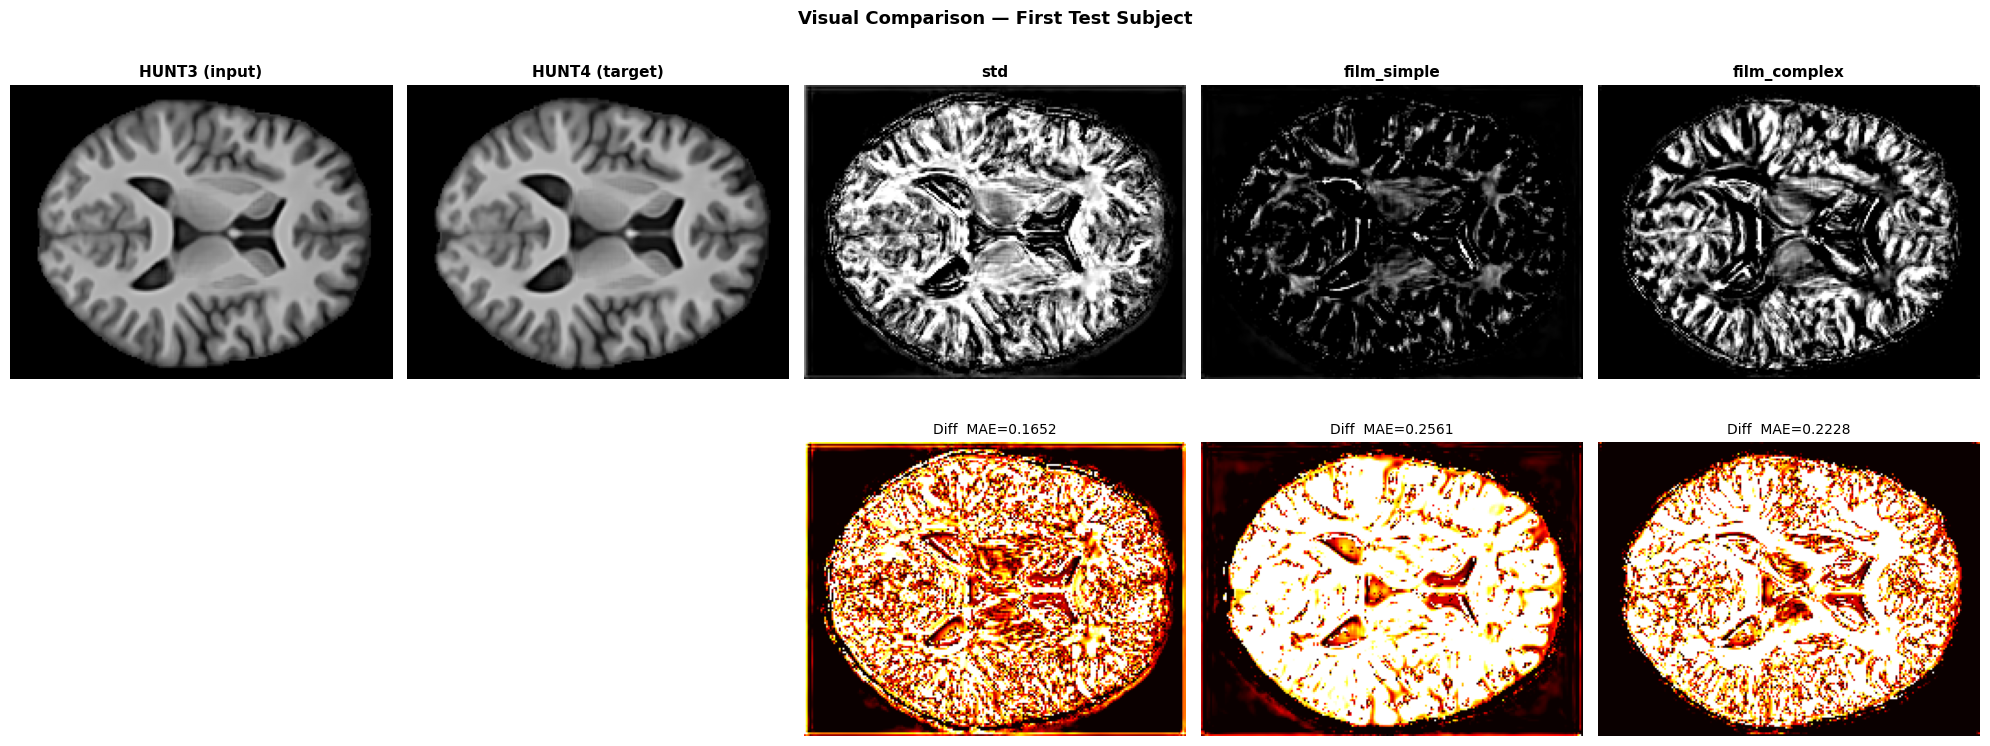

In [ ]:
x_path, y_path = test_pairs[0]

with torch.no_grad():
    recons = {}
    for key, model in champions.items():
        data_device = next(model.parameters()).device
        x_full = data_converter.load_path_as_tensor(x_path, data_device)
        y_full = data_converter.load_path_as_tensor(y_path, data_device)
        x = data_converter.get_volume_with_3d_change(x_full, ((16, 10, 0), (17, 11, 17)), remove_mode=True)
        y = data_converter.get_volume_with_3d_change(y_full, ((16, 10, 0), (17, 11, 17)), remove_mode=True)

        if key.startswith('film'):
            cond = get_metadata_features(cond_loader, x_path).unsqueeze(0).to(data_device)
            out = model(x, cond)
        else:
            out = model(x)
        recons[key] = out[0] if isinstance(out, (tuple, list)) else out

x_sl = get_middle_slice_3D(x)
y_sl = get_middle_slice_3D(y)

panels = [('HUNT3 (input)', x_sl), ('HUNT4 (target)', y_sl)] + \
         [(key, get_middle_slice_3D(recons[key])) for key in recons]

n_cols = len(panels)
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))

for col, (title, sl) in enumerate(panels):
    axes[0, col].imshow(sl, cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(title, fontsize=11, fontweight='bold')
    axes[0, col].axis('off')

    if title not in ('HUNT3 (input)', 'HUNT4 (target)'):
        diff = np.abs(sl - y_sl)
        axes[1, col].imshow(diff, cmap='hot', vmin=0, vmax=0.3)
        axes[1, col].set_title('Diff  MAE={:.4f}'.format(np.mean(diff)), fontsize=10)
        axes[1, col].axis('off')
    else:
        axes[1, col].set_visible(False)

fig.suptitle('Visual Comparison — First Test Subject', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
